In [ ]:
# Audit fix: find this checkout from either the repository root or ipynb/.
# Initialize before training instead of loading plots from an old partial run.
from pathlib import Path
import sys

root = Path.cwd()
if not (root / "src").is_dir():
    root = root.parent
assert (root / "src").is_dir(), "Run from the repository root or ipynb/."
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))


In [12]:
import matplotlib.pyplot as plt
import torch

from experiments import ComparisonConfig, load_datasets, run_comparison
from experiments.plots import (
    summary_table, learning_curves, rollout_curves, physics_curves,
    equation_curves, forcing_curves, field_slices,
)
from nsdata import generate_dataset, save_dataset

torch.set_num_threads(1)
# Audit fix: use the same available device for reference generation and training.
device = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams.update({"font.size": 11, "figure.dpi": 120, "savefig.dpi": 180})


In [14]:
# Generate missing reference trajectories; their RK4/exact solver is independent of learned AVF steps.
data_directory = root / "datasets" / "large"
families = ("wave", "taylor_green", "random")
for family in families:
    path = data_directory / f"{family}.pt"
    if not path.is_file():
        data = generate_dataset(
            family, grid_size=24, n_trajectories=32, n_snapshots=41,
            seed=142, device=device,
        )
        save_dataset(data, path, overwrite=True)
        del data

In [4]:
datasets = load_datasets(data_directory, families)
config = ComparisonConfig(
    # Audit fix: share the device selected above and make the comparison integrator explicit.
    device=device,
    integration_method="avf",
    cutoff=(7, 7, 7),
    train_indices=tuple(range(24)),
    validation_indices=tuple(range(24, 28)),
    test_indices=tuple(range(28, 32)),
    seeds=(8, 18, 28),
    # This counts minibatches; the default accumulation schedule makes 616 Adam updates.
    steps=3000,
    batch_size=24,
    eval_every=100,
)
output = root / "results" / "local_smoke_test_seeds_8_18_28"

NameError: name 'load_datasets' is not defined

In [12]:
# Train on observed transitions, select on validation, and roll out with the same AVF settings.
# Plot only this completed run; old AVF retry artifacts contain unequal, incomplete seed sets.
results = run_comparison(datasets, config, output)

NameError: name 'run_comparison' is not defined

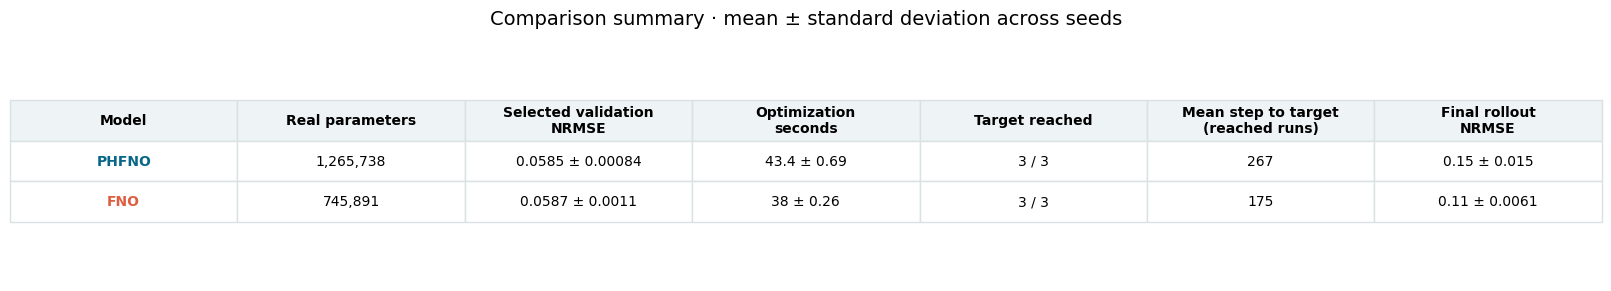

In [13]:
figure = summary_table(results)
plt.show()

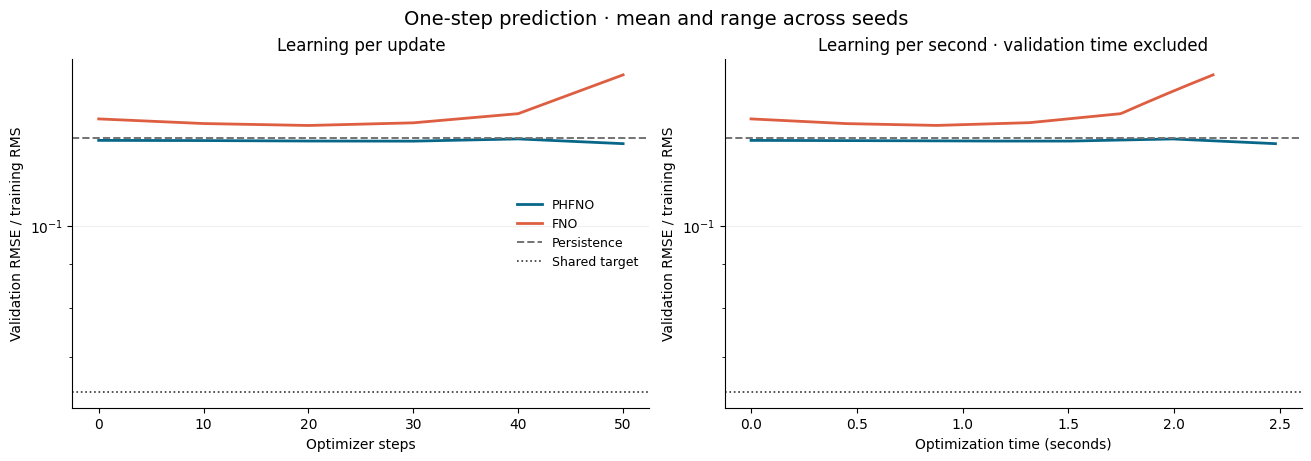

In [10]:
figure = learning_curves(results)
plt.show()

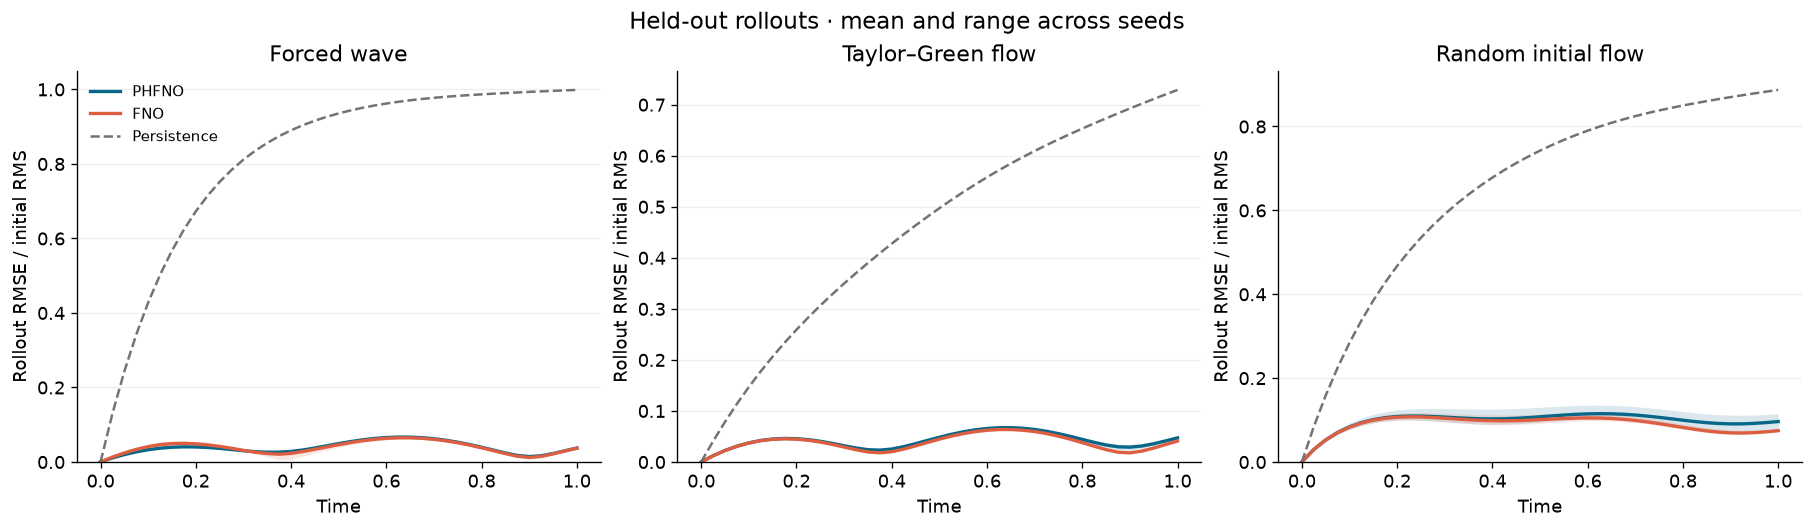

In [7]:
figure = rollout_curves(results)
plt.show()

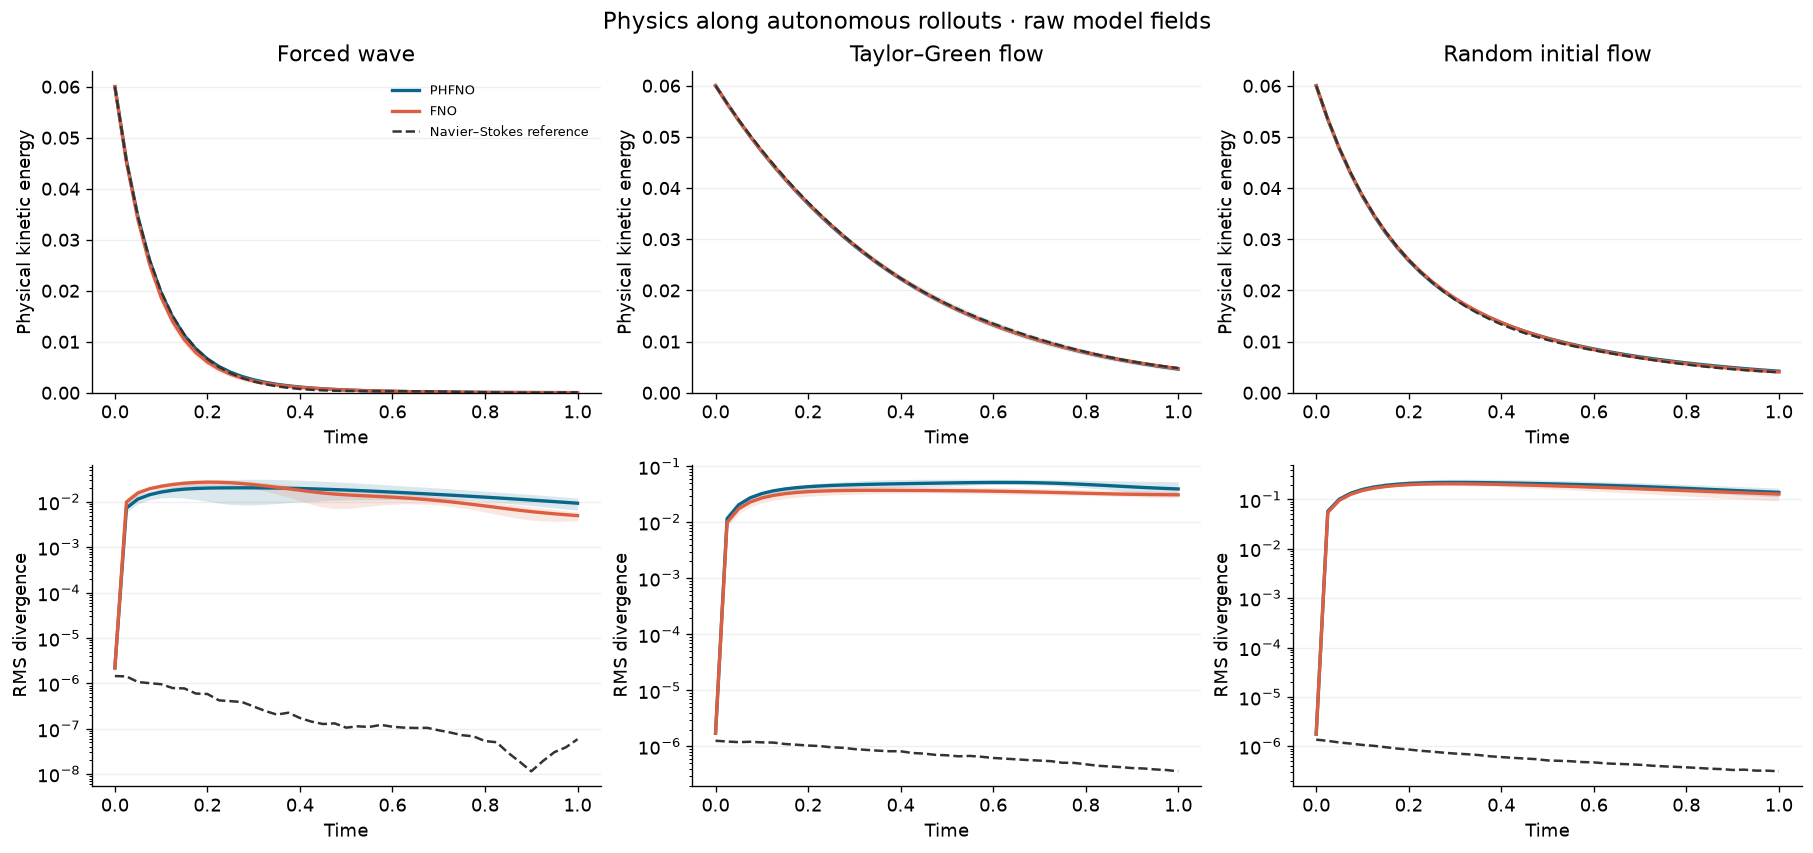

In [8]:
figure = physics_curves(results)
plt.show()

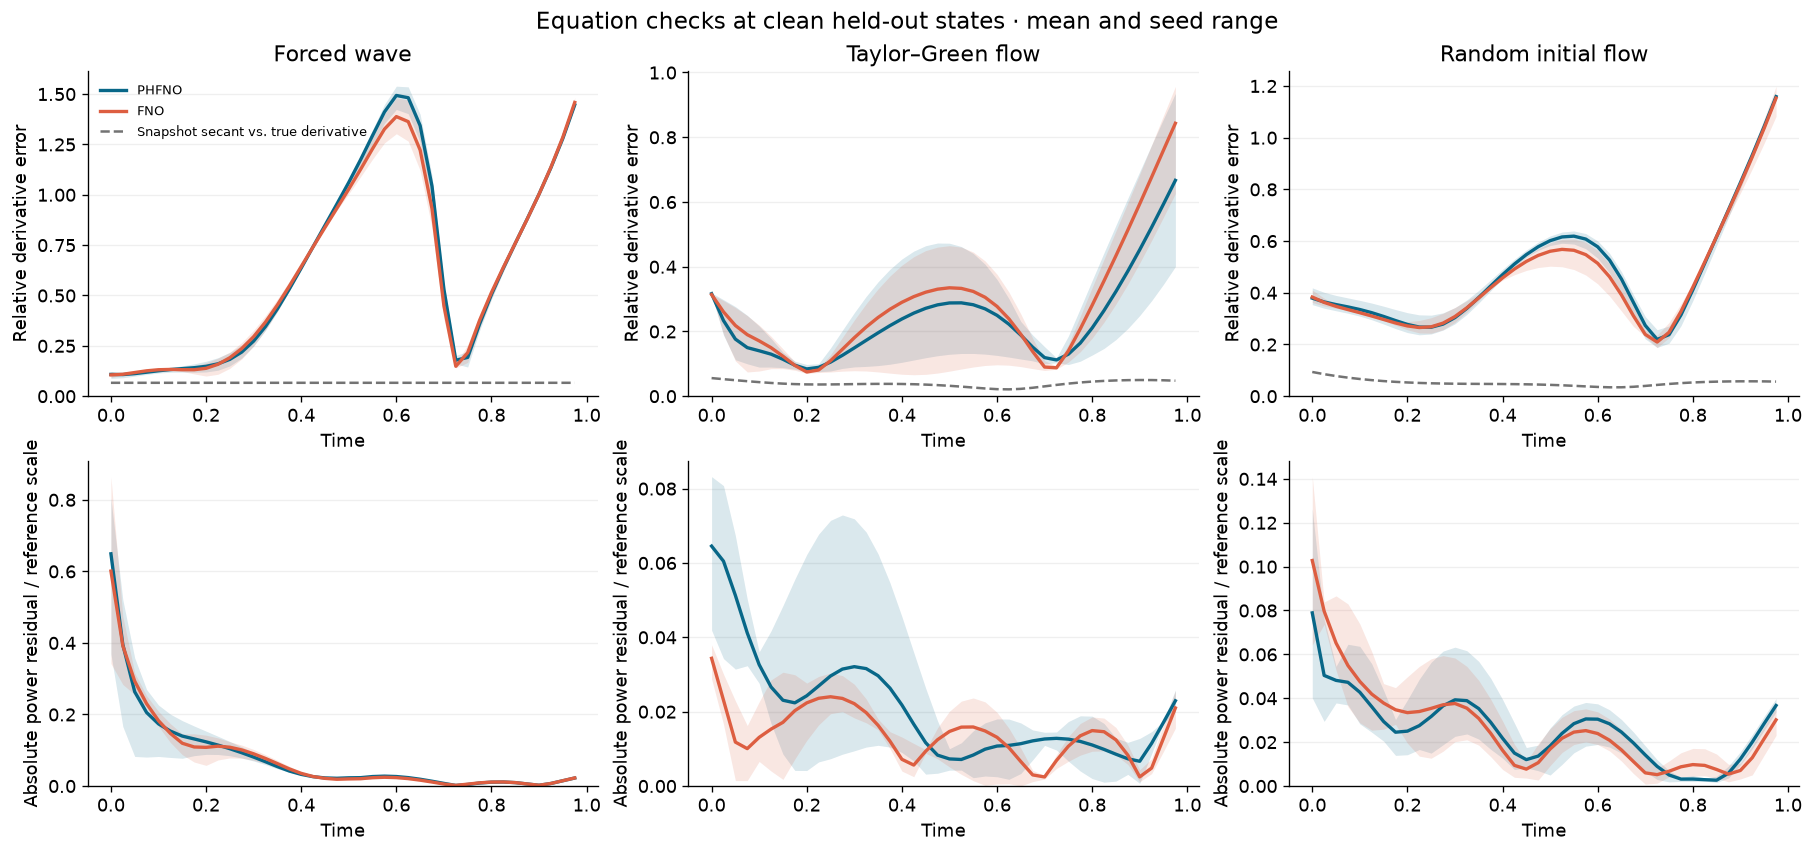

In [9]:
figure = equation_curves(results)
plt.show()

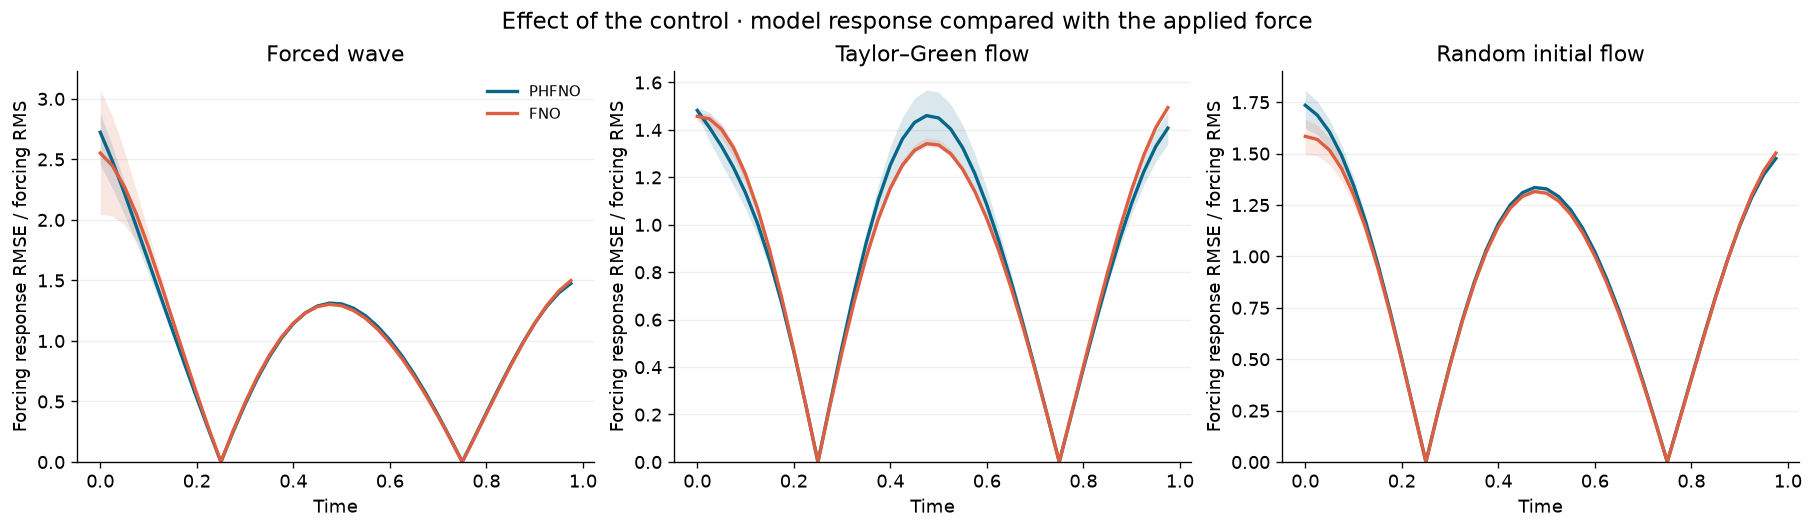

In [10]:
figure = forcing_curves(results)
plt.show()

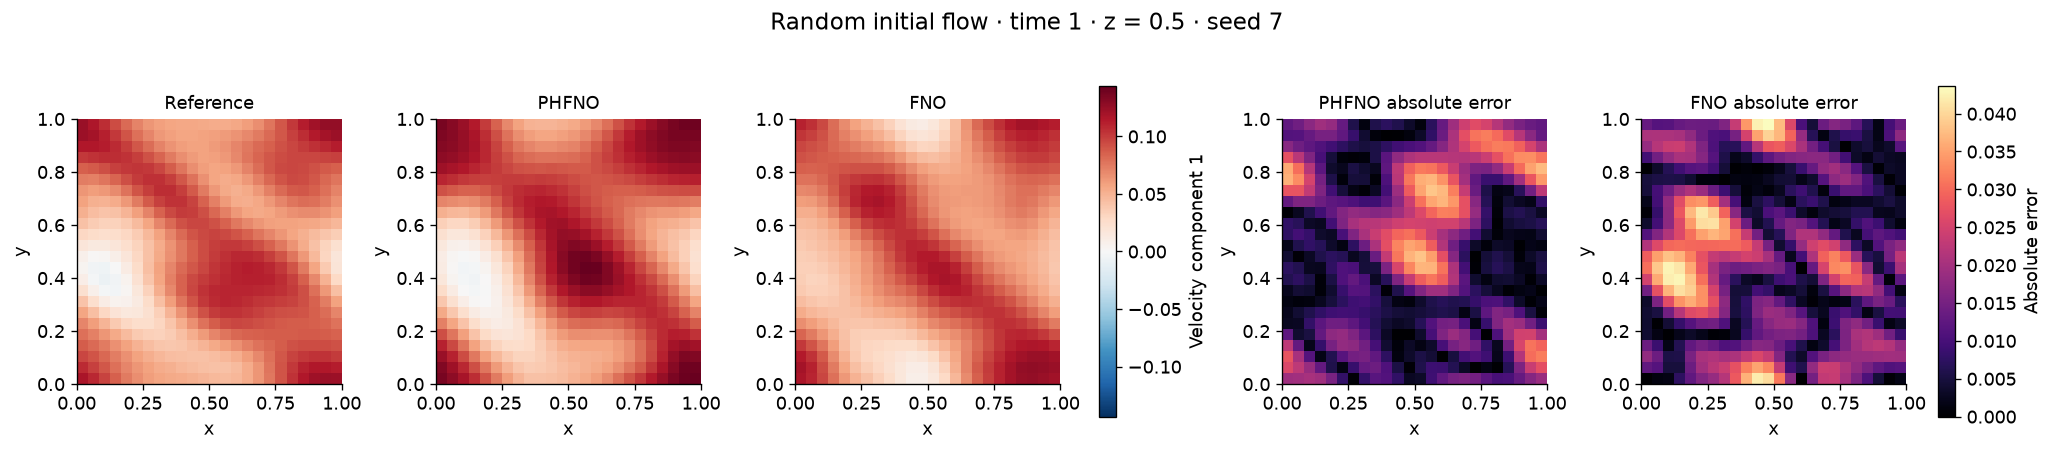

In [11]:
figure = field_slices(results, family="random", seed=config.seeds[0])
plt.show()